# 02_eda.ipynb

## Chuẩn bị dữ liệu

In [3]:
%run 00_core.ipynb

In [4]:
prior_items = load_csv(PATHS.data_file("prior_items.csv"))
order_time = load_csv(PATHS.data_file("order_time.csv"))
product_catalog = load_csv(PATHS.data_file("product_catalog.csv"))

analyzer = BehaviorAnalyzer()

basket_stats = analyzer.basket_stats(prior_items)
basket_ranges = analyzer.basket_ranges(prior_items)
orders_by_day = analyzer.orders_by_day(order_time, prior_items)
orders_by_hour = analyzer.orders_by_hour(order_time, prior_items)
top_products = analyzer.top_products(prior_items, product_catalog)
top_categories = analyzer.top_categories(prior_items, product_catalog)
reordered_products = analyzer.reordered_products(prior_items, product_catalog)

In [5]:
save_csv(basket_stats, PATHS.table_file("basket_stats.csv"))
save_csv(basket_ranges, PATHS.table_file("basket_ranges.csv"))
save_csv(orders_by_day, PATHS.table_file("orders_by_day.csv"))
save_csv(orders_by_hour, PATHS.table_file("orders_by_hour.csv"))
save_csv(top_products, PATHS.table_file("top_products.csv"))
save_csv(top_categories, PATHS.table_file("top_categories.csv"))
save_csv(reordered_products, PATHS.table_file("reordered_products.csv"))

## Giỏ hàng

In [6]:
basket_stats

,Chỉ tiêu,Số sản phẩm
0,Nhỏ nhất,2.00
1,Q1,5.00
2,Trung vị,9.00
3,Trung bình,10.55
4,Q3,14.00
5,Lớn nhất,145.00
6,Độ lệch chuẩn,7.42


In [18]:
basket_ranges

,Nhóm giỏ hàng,Số đơn hàng,Tỷ trọng (%)
0,2–5,844431,27.61
1,6–10,1000952,32.73
2,11–20,909333,29.73
3,21–40,289722,9.47
4,Trên 40,13688,0.45


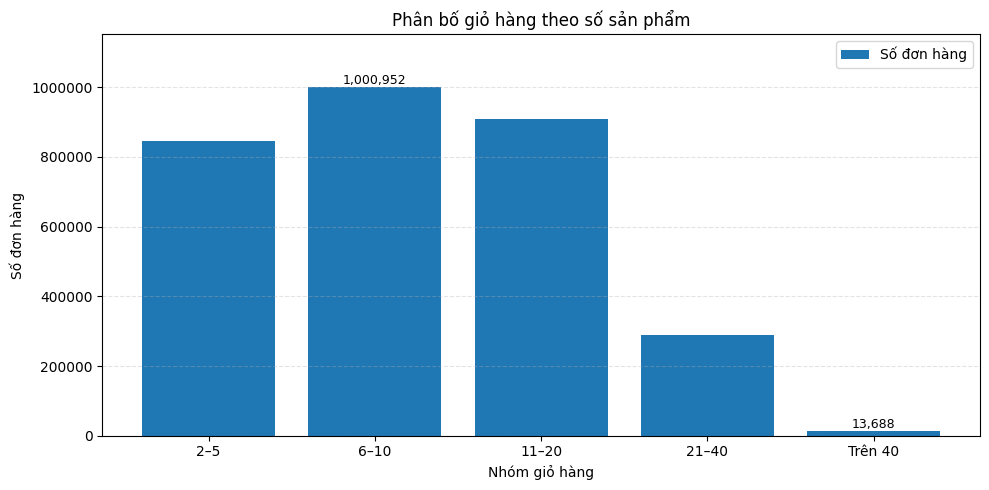

In [7]:
PLOT.bar_vertical(
    basket_ranges,
    x="Nhóm giỏ hàng",
    y="Số đơn hàng",
    title="Phân bố giỏ hàng theo số sản phẩm",
    filename="basket_ranges.png"
)

## Thời điểm mua hàng

In [8]:
orders_by_day

,Ngày trong tuần,Số đơn hàng
0,Chủ nhật,557772
1,Thứ hai,556705
2,Thứ ba,441955
3,Thứ tư,412400
4,Thứ năm,401212
5,Thứ sáu,425982
6,Thứ bảy,418848


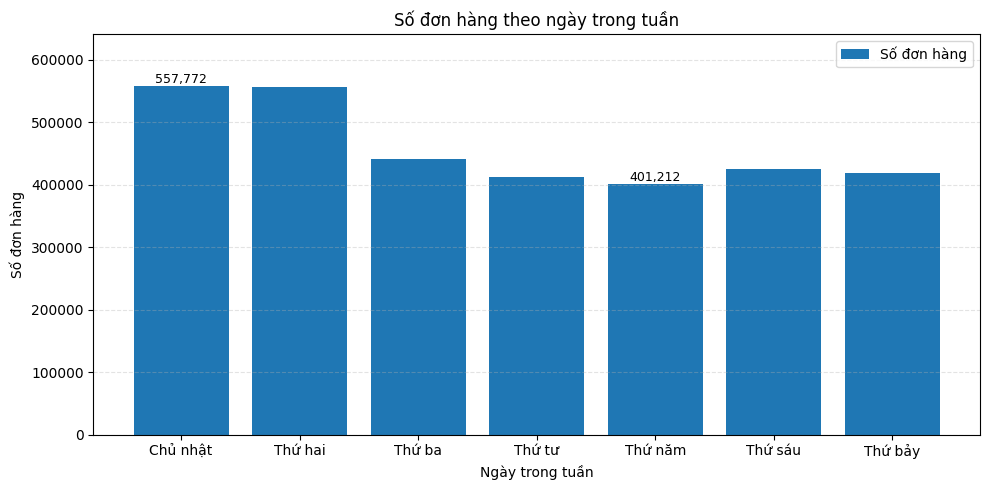

In [9]:
PLOT.bar_vertical(
    orders_by_day,
    x="Ngày trong tuần",
    y="Số đơn hàng",
    title="Số đơn hàng theo ngày trong tuần",
    filename="orders_by_day.png",
)

In [10]:
orders_by_hour

,Giờ trong ngày,Số đơn hàng
0,0,21372
1,1,11596
2,2,7070
3,3,5120
4,4,5175
5,5,8972
6,6,28792
7,7,86656
8,8,168321
9,9,243496


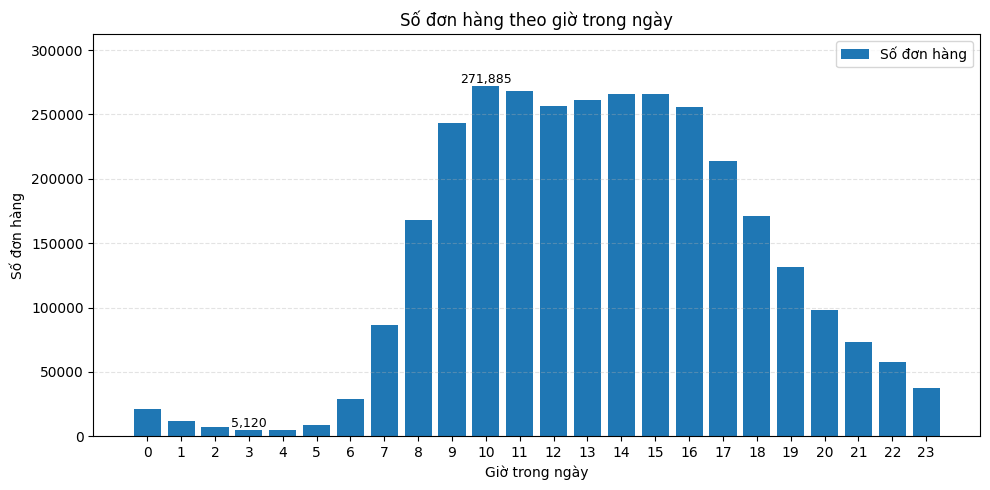

In [11]:
PLOT.bar_vertical(
    orders_by_hour,
    x="Giờ trong ngày",
    y="Số đơn hàng",
    title="Số đơn hàng theo giờ trong ngày",
    filename="orders_by_hour.png",
)

## Sản phẩm được mua nhiều nhất

In [12]:
top_products

,Sản phẩm,Số lần mua
3681,Banana,472565
3477,Bag of Organic Bananas,379450
31898,Organic Strawberries,264683
28807,Organic Baby Spinach,241921
30268,Organic Hass Avocado,213584
28771,Organic Avocado,176815
22401,Large Lemon,152657
32459,Organic Whole Milk,147747
42879,Strawberries,142951
23408,Limes,140627


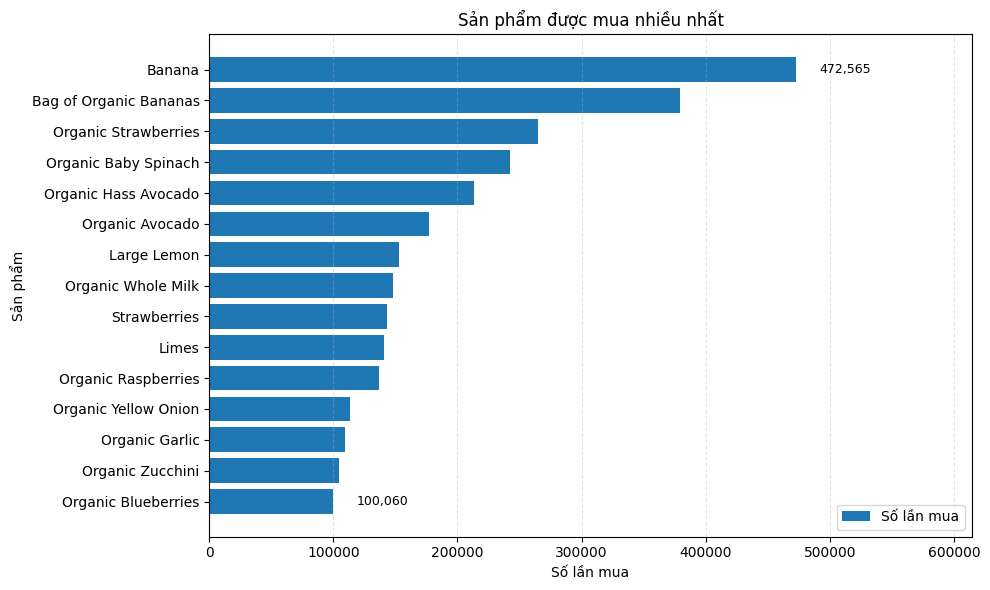

In [13]:
PLOT.bar_horizontal(
    top_products,
    x="Sản phẩm",
    y="Số lần mua",
    title="Sản phẩm được mua nhiều nhất",
    filename="top_products.png",
)

## Nhóm hàng nổi bật

In [14]:
top_categories

,Nhóm hàng lớn,Số lần mua,Tỷ trọng trong tổng số lần mua (%)
19,produce,9479291,29.23
7,dairy eggs,5414016,16.69
20,snacks,2887550,8.90
3,beverages,2690129,8.29
10,frozen,2236432,6.90
16,pantry,1875577,5.78
2,bakery,1176787,3.63
6,canned goods,1068058,3.29
8,deli,1051249,3.24
9,dry goods pasta,866627,2.67


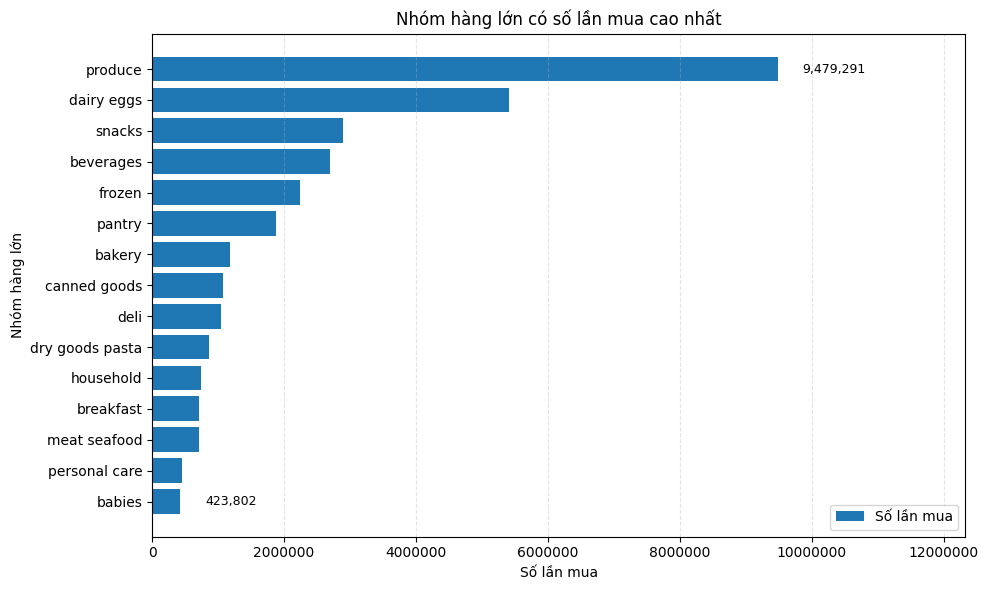

In [15]:
PLOT.bar_horizontal(
    top_categories,
    x="Nhóm hàng lớn",
    y="Số lần mua",
    title="Nhóm hàng lớn có số lần mua cao nhất",
    filename="top_categories.png",
)

## Sản phẩm được mua lại nhiều nhất

In [16]:
reordered_products

,Sản phẩm,Số lần mua,Số lần mua lại,Tỷ lệ mua lại (%)
3681,Banana,472565,398609,84.35
3477,Bag of Organic Bananas,379450,315913,83.26
31898,Organic Strawberries,264683,205845,77.77
28807,Organic Baby Spinach,241921,186884,77.25
30268,Organic Hass Avocado,213584,170131,79.66
28771,Organic Avocado,176815,134044,75.81
32459,Organic Whole Milk,147747,122789,83.11
22401,Large Lemon,152657,106255,69.60
31340,Organic Raspberries,137057,105409,76.91
42879,Strawberries,142951,99802,69.82


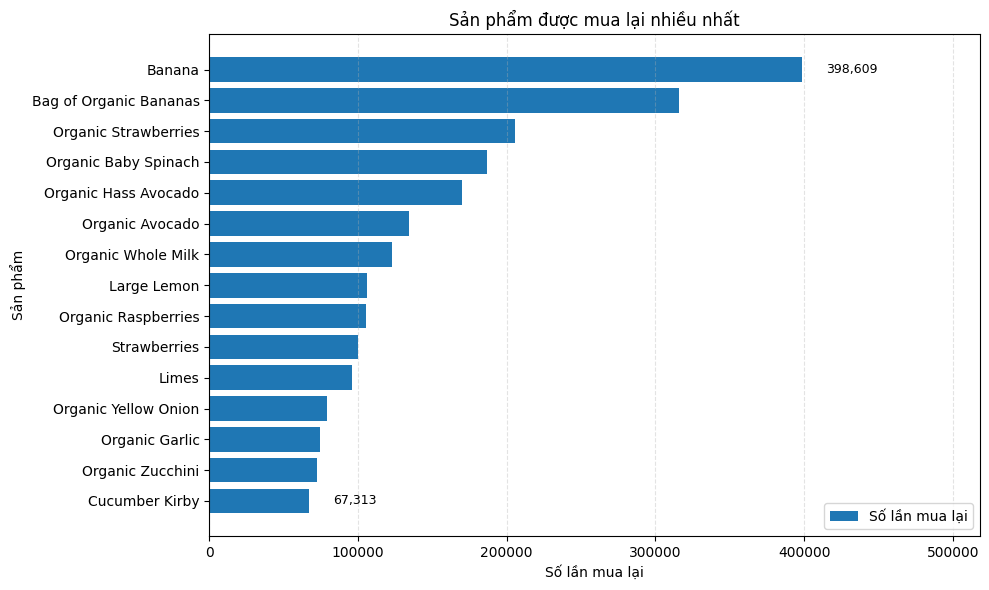

In [17]:
PLOT.bar_horizontal(
    reordered_products,
    x="Sản phẩm",
    y="Số lần mua lại",
    title="Sản phẩm được mua lại nhiều nhất",
    filename="reordered_products.png",
)